In [2]:
%matplotlib inline
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.signal as signal
import tdt
from textgrid import TextGrid

In [3]:
# Load TDT data, tracking files, and the TextGrid.
data = tdt.read_block('../data/allie/tank')
tracking_dir = Path('../data/allie/tracking_cleaned')
tracking_files = sorted(
    tracking_dir.glob('*_cleaned.csv'),
    key=lambda path: int(re.search(r'T(\d+)', path.name).group(1)),
)
textgrid_path = Path('../data/allie/noise_removed_aligned.TextGrid')
textgrid = TextGrid.fromFile(str(textgrid_path))
segment_tier = next(tier for tier in textgrid.tiers if tier.name == 'sentence')
speech_intervals = [
    {'start': interval.minTime, 'end': interval.maxTime, 'text': interval.mark.strip()}
    for interval in segment_tier.intervals
    if interval.mark.strip()
]

# Select TDT trial pairs by the trial numbers present in the tracking filenames.
motive_frame_times = np.asarray(data.epocs.fmIn['onset'])
stim_onsets = np.asarray(data.epocs.stim['onset'])
cue_onsets = np.asarray(data.epocs.cue_['onset'])
trial_markers = np.asarray(data.epocs.tri_['onset'])
if len(trial_markers) % 2:
    raise ValueError(f'Expected an even number of trial-bound markers, found {len(trial_markers)}')

all_trial_bounds = trial_markers.reshape(-1, 2)
tracking_trial_numbers = [
    int(re.search(r'T(\d+)', path.name).group(1))
    for path in tracking_files
]
if len(tracking_trial_numbers) != len(set(tracking_trial_numbers)):
    raise ValueError(f'Duplicate tracking trial numbers: {tracking_trial_numbers}')
if any(number < 1 or number > len(all_trial_bounds) for number in tracking_trial_numbers):
    raise ValueError('A tracking filename refers to a TDT trial outside the available range')

mic_data = np.asarray(data.streams.Mic1.data)
mic_fs = data.streams.Mic1.fs
mic_time = np.arange(len(mic_data)) / mic_fs
mic_envelope = np.abs(signal.hilbert(mic_data))
filter_b, filter_a = signal.butter(4, 5 / (mic_fs / 2), btype='low')
mic_envelope = signal.filtfilt(filter_b, filter_a, mic_envelope)
mic_envelope = (mic_envelope - mic_envelope.min()) / (
    mic_envelope.max() - mic_envelope.min()
)

trials = []
for trial_number, tracking_file in zip(tracking_trial_numbers, tracking_files):
    start, end = all_trial_bounds[trial_number - 1]
    motive_mask = (motive_frame_times >= start) & (motive_frame_times < end)
    cue_trial_times = cue_onsets[(cue_onsets >= start) & (cue_onsets < end)] - start
    stim_trial_times = stim_onsets[(stim_onsets >= start) & (stim_onsets < end)] - start
    motive_times = motive_frame_times[motive_mask] - start
    if len(motive_times) == 0:
        raise ValueError(f'No motive frames found for trial {trial_number}')

    mocap_data = pd.read_csv(tracking_file)
    mocap_data['Time'] -= mocap_data['Time'].iloc[0]
    mocap_data['Time'] += motive_times[0]
    mocap_fs = 1 / np.median(np.diff(mocap_data['Time']))
    raw_speed = mocap_data['RHand_Speed'].to_numpy()
    speed_b, speed_a = signal.butter(4, 5 / (mocap_fs / 2), btype='low')
    filtered_speed = signal.filtfilt(speed_b, speed_a, raw_speed)
    normalized_speed = (filtered_speed - filtered_speed.min()) / (
        filtered_speed.max() - filtered_speed.min()
    )

    trial_speech = [
        interval for interval in speech_intervals
        if start <= interval['start'] < end
    ]
    first_speech = trial_speech[0] if trial_speech else None
    visual_onset = stim_trial_times[0] if len(stim_trial_times) else np.nan
    cue_onset = cue_trial_times[0] if len(cue_trial_times) else np.nan
    speech_onset = first_speech['start'] if first_speech else np.nan

    trial_mic_mask = (mic_time >= start) & (mic_time <= end)
    trial_mic_time = mic_time[trial_mic_mask] - start
    trial_signal = mic_envelope[trial_mic_mask]
    mic_on_mocap_time = np.interp(
        mocap_data['Time'].to_numpy(),
        trial_mic_time,
        trial_signal,
    )

    trials.append({
        'index': trial_number,
        'tracking_file': tracking_file,
        'start': start,
        'end': end,
        'motive_times': motive_times,
        'cue_onsets': cue_trial_times,
        'stim_onsets': stim_trial_times,
        'mocap_data': mocap_data,
        'normalized_rhand_speed': normalized_speed,
        'mic_envelope_on_mocap_time': mic_on_mocap_time,
        'speech_text': first_speech['text'] if first_speech else None,
        'speech_onset_trial_seconds': speech_onset - start if first_speech else np.nan,
        'visual_onset_trial_seconds': visual_onset,
        'cue_onset_trial_seconds': cue_onset,
        'cue_delay_seconds': cue_onset - visual_onset
            if not np.isnan(cue_onset) and not np.isnan(visual_onset) else np.nan,
        'cue_to_speech_rt': speech_onset - (start + cue_onset)
            if first_speech and not np.isnan(cue_onset) else np.nan,
    })

speech_onsets = pd.DataFrame([
    {
        'trial': trial['index'],
        'tracking_file': trial['tracking_file'].name,
        'speech_text': trial['speech_text'],
        'speech_onset_trial_seconds': trial['speech_onset_trial_seconds'],
        'visual_onset_trial_seconds': trial['visual_onset_trial_seconds'],
        'cue_onset_trial_seconds': trial['cue_onset_trial_seconds'],
        'cue_delay_seconds': trial['cue_delay_seconds'],
        'cue_to_speech_rt': trial['cue_to_speech_rt'],
    }
    for trial in trials
])
print(f'Prepared {len(trials)} matched trials from {len(all_trial_bounds)} TDT trials')

Found Synapse note file: ../data/allie/tank\Notes.txt
read from t=0s to t=507.19s
info: stim iCon epoc detected - extracting onset/offset timestamps from data values 3 and 4
info: fmIn iCon epoc detected - extracting onset/offset timestamps from data values 3 and 4
Prepared 39 matched trials from 40 TDT trials


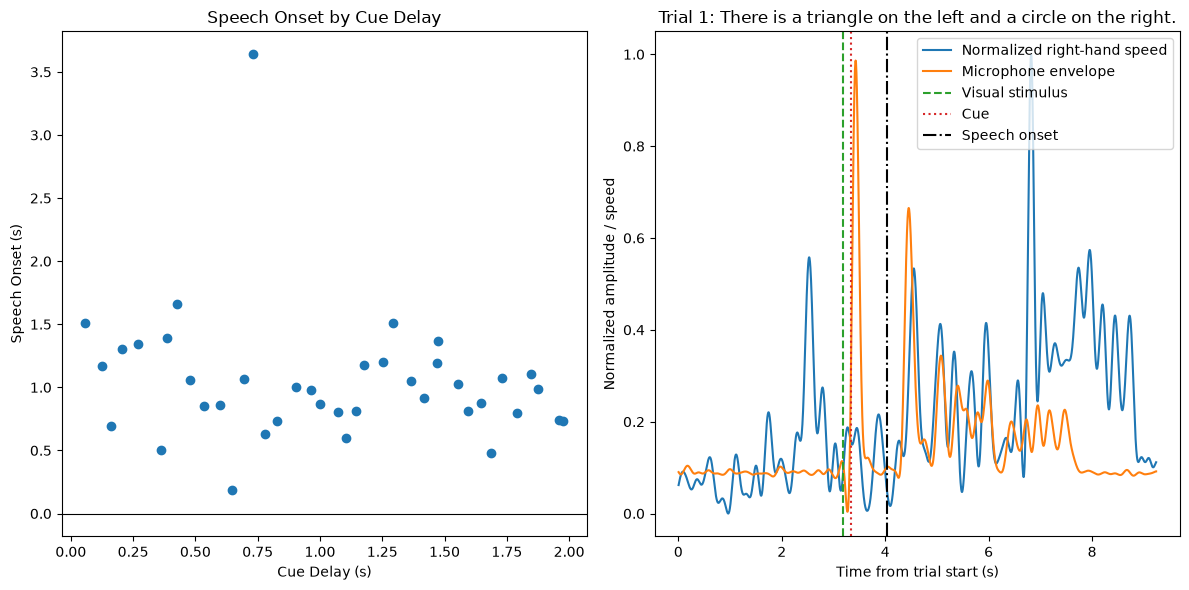

In [4]:
# Plot RT versus visual-to-cue delay and the aligned time course for one sample trial.
sample_trial_number = 1
sample_trial = next(trial for trial in trials if trial['index'] == sample_trial_number)

fig, (rt_ax, trial_ax) = plt.subplots(1, 2, figsize=(12, 6))

valid_rt = speech_onsets.dropna(subset=['cue_delay_seconds', 'cue_to_speech_rt'])
rt_ax.scatter(
    valid_rt['cue_delay_seconds'],
    valid_rt['cue_to_speech_rt'],
    color='tab:blue',
)
rt_ax.axhline(0, color='black', linewidth=0.8)
rt_ax.set(
    title='Speech Onset by Cue Delay',
    xlabel='Cue Delay (s)',
    ylabel='Speech Onset (s)',
)

trial_time = sample_trial['mocap_data']['Time']
trial_ax.plot(
    trial_time,
    sample_trial['normalized_rhand_speed'],
    label='Normalized right-hand speed',
    color='tab:blue',
)
trial_ax.plot(
    trial_time,
    sample_trial['mic_envelope_on_mocap_time'],
    label='Microphone envelope',
    color='tab:orange',
)
for onset in sample_trial['stim_onsets']:
    trial_ax.axvline(onset, color='tab:green', linestyle='--', label='Visual stimulus')
for onset in sample_trial['cue_onsets']:
    trial_ax.axvline(onset, color='tab:red', linestyle=':', label='Cue')
if not np.isnan(sample_trial['speech_onset_trial_seconds']):
    trial_ax.axvline(
        sample_trial['speech_onset_trial_seconds'],
        color='black',
        linestyle='-.',
        label='Speech onset',
    )
trial_ax.set(
    title=f"Trial {sample_trial['index']}: {sample_trial['speech_text']}",
    xlabel='Time from trial start (s)',
    ylabel='Normalized amplitude / speed',
)
handles, labels = trial_ax.get_legend_handles_labels()
unique_handles = dict(zip(labels, handles))
trial_ax.legend(unique_handles.values(), unique_handles.keys())

fig.tight_layout()
plt.show()